# 02 — Weather Cleaning

**Phase 2, Step 1** of the forecasting pipeline.

**Input:**   `data/interim/weather_hourly_raw.csv`  (from notebook 01)
**Output:**  `data/interim/weather_hourly_clean.csv`
            `data/interim/weather_daily_clean.csv`

---

## What this notebook does

1. **Drop empty columns** — Open-Meteo returned 4 always-NaN variables for
   this archive window; they provide no information.
2. **Align the hourly grid** — reindex every city to a continuous hourly
   timeline so downstream lag features can assume a regular cadence.
3. **Clip physically impossible values** — e.g. humidity > 100%, negative
   precipitation. Counts are logged.
4. **Interpolate short gaps (≤ 6 h)** — time-linear inside each city.
5. **Flag statistical outliers** — monthly IQR × 3 per city. Non-destructive:
   the forecasting models still see the real values and a boolean
   `<var>_outlier` column tells the FE step what to down-weight.
6. **Resample to daily** — with **circular**, **speed-weighted** wind
   direction. This is critical: averaging 350° and 10° naively gives 180°,
   the exact opposite of reality.

All logic lives in **`src/weather/cleaning.py`**; this notebook orchestrates,
inspects, and QCs.

## 1. Setup

In [14]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

from src.weather import cleaning
from src.utils.config import INTERIM_DIR, FORECAST_TARGETS
from src.utils.logging_utils import get_logger
logger = get_logger("nb.02_cleaning")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Load the raw hourly frame and audit quality

Before touching anything, we need a quantitative picture of what's broken.
The cleaning rules are driven by this audit, not by guesswork.

In [15]:
raw_hourly = pd.read_csv(INTERIM_DIR / "weather_hourly_raw.csv", parse_dates=["date"])
if raw_hourly["date"].dt.tz is None:
    raw_hourly["date"] = raw_hourly["date"].dt.tz_localize("UTC")
print(f"Raw hourly: {raw_hourly.shape[0]:,} rows x {raw_hourly.shape[1]} cols")
print(f"Cities    : {sorted(raw_hourly['City'].unique())}")
print(f"Date range: {raw_hourly['date'].min()}  ->  {raw_hourly['date'].max()}")

Raw hourly: 276,000 rows x 26 cols
Cities    : ['Baku', 'Ganja', 'Guba', 'Lankaran', 'Zaqatala']
Date range: 2020-01-01 00:00:00+00:00  ->  2026-04-18 23:00:00+00:00


### 2a. Missingness profile

In [16]:
miss = (raw_hourly.isna().mean() * 100).round(2).sort_values(ascending=False)
miss_nonzero = miss[miss > 0]
print("Columns with any missingness (% of rows):")
print(miss_nonzero.to_string() if len(miss_nonzero) else "  (none)")

Columns with any missingness (% of rows):
temperature_80m       100.0
wind_direction_80m    100.0
wind_speed_80m        100.0
evapotranspiration    100.0


### 2b. Time-grid integrity per city

In [17]:
rows = []
for city, g in raw_hourly.groupby("City"):
    diffs = g["date"].sort_values().diff().dropna()
    rows.append({
        "City": city,
        "rows": len(g),
        "duplicates": int(g["date"].duplicated().sum()),
        "non_1h_steps": int((diffs != pd.Timedelta(hours=1)).sum()),
        "span_days": (g["date"].max() - g["date"].min()).days,
    })
pd.DataFrame(rows)

,City,rows,duplicates,non_1h_steps,span_days
0,Baku,55200,0,0,2299
1,Ganja,55200,0,0,2299
2,Guba,55200,0,0,2299
3,Lankaran,55200,0,0,2299
4,Zaqatala,55200,0,0,2299


### 2c. Physical-range violations

In [18]:
from src.weather.cleaning import PHYSICAL_RANGES
violation_rows = []
for col, (lo, hi) in PHYSICAL_RANGES.items():
    if col not in raw_hourly.columns:
        continue
    s = raw_hourly[col].dropna()
    below = int((s < lo).sum())
    above = int((s > hi).sum())
    violation_rows.append({
        "variable": col, "min": round(s.min(), 2), "max": round(s.max(), 2),
        f"below_{lo}": below, f"above_{hi}": above,
    })
pd.DataFrame(violation_rows)

,variable,min,max,below_-60.0,above_60.0,below_0.0,above_100.0,above_300.0,above_20.0,above_80.0,above_360.0,above_120.0,below_-50.0,above_70.0,above_3600.0,above_1500.0
0,temperature_2m,-15.70,40.05,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,relative_humidity_2m,7.53,100.00,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dew_point_2m,-30.50,26.90,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,precipitation,0.00,23.90,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,rain,0.00,23.90,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,cloud_cover,0.00,100.00,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,cloud_cover_low,0.00,100.00,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,cloud_cover_mid,0.00,100.00,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,cloud_cover_high,0.00,100.00,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,vapour_pressure_deficit,0.00,6.25,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Run the cleaning pipeline

`clean_weather_pipeline` wraps every step (drop → align → clip → interpolate
→ outlier-flag → daily-resample) and persists both artefacts.

In [19]:
hourly_clean, daily_clean = cleaning.clean_weather_pipeline()
print(f"hourly_clean: {hourly_clean.shape}")
print(f"daily_clean : {daily_clean.shape}")

00:38:34 | INFO    | src.weather.cleaning | ========================================================================
00:38:34 | INFO    | src.weather.cleaning | PHASE 2.1 - Weather Cleaning starting
00:38:34 | INFO    | src.weather.cleaning | Reading C:\Users\User\Desktop\ARIAN\data\interim\weather_hourly_raw.csv
00:38:34 | INFO    | src.weather.cleaning | ========================================================================
00:38:38 | INFO    | src.weather.cleaning | --- clean_hourly: input shape (276000, 26) ---
00:38:38 | INFO    | src.weather.cleaning | Dropping 4 empty columns (miss >= 99.9%): ['evapotranspiration', 'wind_speed_80m', 'wind_direction_80m', 'temperature_80m']
00:38:39 | INFO    | src.weather.cleaning | Interpolated short gaps (<=6h) in 20 columns
00:38:40 | INFO    | src.weather.cleaning | Flagged temperature_2m               outliers: 30 (0.011%)
00:38:40 | INFO    | src.weather.cleaning | Flagged wind_speed_10m               outliers: 934 (0.338%)
00:38:40 | IN

hourly_clean: (276000, 27)
daily_clean : (11500, 24)


## 4. Inspect the cleaned output

### 4a. Columns dropped / added

In [20]:
dropped = sorted(set(raw_hourly.columns) - set(hourly_clean.columns))
added   = sorted(set(hourly_clean.columns) - set(raw_hourly.columns))
print(f"Dropped ({len(dropped)}):", dropped)
print(f"Added   ({len(added)}):", added)

Dropped (4): ['evapotranspiration', 'temperature_80m', 'wind_direction_80m', 'wind_speed_80m']
Added   (5): ['precipitation_outlier', 'rain_outlier', 'temperature_2m_outlier', 'wind_direction_10m_outlier', 'wind_speed_10m_outlier']


### 4b. Outlier flags — counts per city × variable

In [21]:
flag_cols = [c for c in hourly_clean.columns if c.endswith("_outlier")]
flag_summary = (
    hourly_clean.groupby("City")[flag_cols].sum().astype(int)
)
flag_summary

,temperature_2m_outlier,wind_speed_10m_outlier,wind_direction_10m_outlier,rain_outlier,precipitation_outlier
City,,,,,
Baku,9,1,0,0,0
Ganja,0,534,0,0,0
Guba,10,125,0,384,387
Lankaran,11,46,0,865,874
Zaqatala,0,228,0,0,0


### 4c. Visual QC — distribution of flagged vs clean observations

Red dots are flagged outliers — they should sit in the tails, not the body.

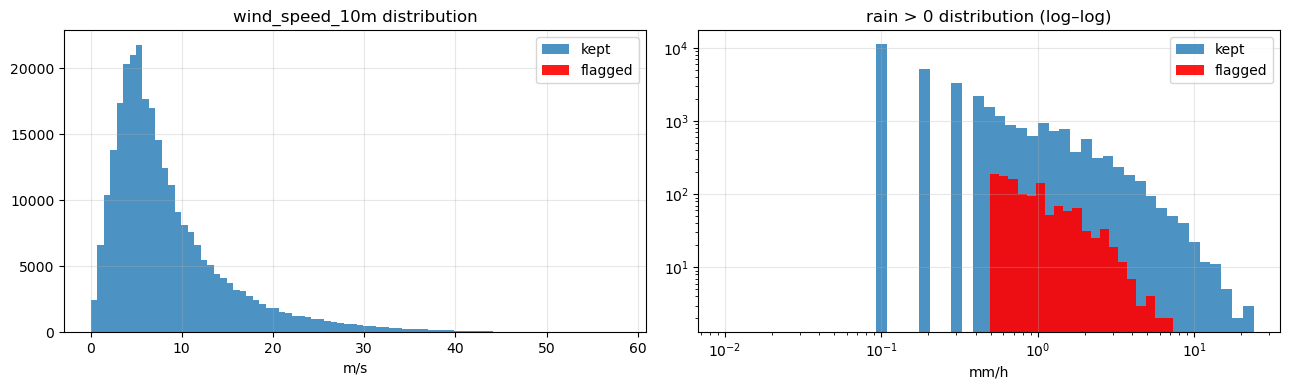

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Wind speed — most flagged variable
ax = axes[0]
good = hourly_clean[~hourly_clean["wind_speed_10m_outlier"]]
bad  = hourly_clean[ hourly_clean["wind_speed_10m_outlier"]]
ax.hist(good["wind_speed_10m"], bins=80, alpha=0.8, label="kept")
ax.hist(bad["wind_speed_10m"],  bins=80, alpha=0.9, color="red", label="flagged")
ax.set_title("wind_speed_10m distribution")
ax.set_xlabel("m/s"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
good = hourly_clean[~hourly_clean["rain_outlier"]]
bad  = hourly_clean[ hourly_clean["rain_outlier"]]
# log-scale y for rain; positive bins only
pos = good[good["rain"] > 0]["rain"]
ax.hist(pos, bins=np.logspace(-2, np.log10(max(pos.max(), 1)), 50), alpha=0.8, label="kept")
if len(bad):
    ax.hist(bad["rain"], bins=np.logspace(-2, np.log10(max(bad['rain'].max(), 1)), 50),
            alpha=0.9, color="red", label="flagged")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("rain > 0 distribution (log–log)")
ax.set_xlabel("mm/h"); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

### 4d. Temperature trace per city (sanity check)

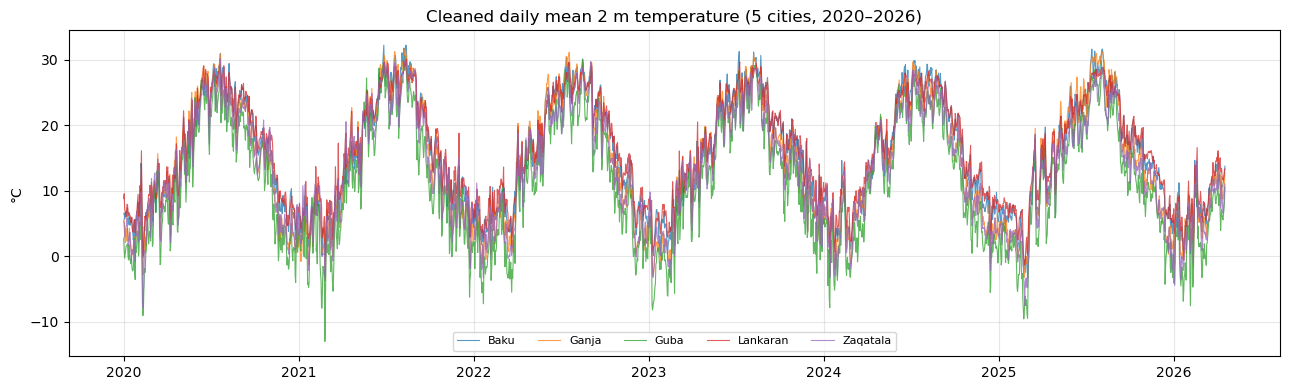

In [23]:
fig, ax = plt.subplots(figsize=(13, 4))
for city, g in hourly_clean.groupby("City"):
    d = g.set_index("date")["temperature_2m"].resample("D").mean()
    ax.plot(d.index, d.values, lw=0.8, alpha=0.75, label=city)
ax.set_title("Cleaned daily mean 2 m temperature (5 cities, 2020–2026)")
ax.set_ylabel("°C"); ax.legend(ncol=5, fontsize=8, loc="lower center")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. Daily frame — verify circular wind statistics

Wind direction must be aggregated with unit vectors, not scalar means.
Let's confirm: plot +a wind rose-style polar distribution for one city-year
and inspect the dominant quadrant.

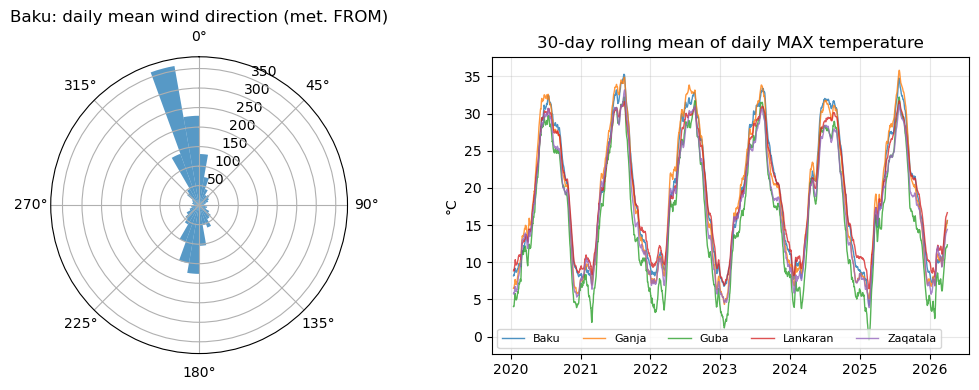

In [24]:
fig = plt.figure(figsize=(11, 4))

# Polar plot of wind direction (speed-weighted daily circular mean)
sub = daily_clean[daily_clean["City"] == "Baku"].copy()
dir_rad = np.deg2rad(sub["wind_direction_10m"])

ax1 = fig.add_subplot(1, 2, 1, projection="polar")
ax1.set_theta_zero_location("N"); ax1.set_theta_direction(-1)
ax1.hist(dir_rad, bins=36, alpha=0.75)
ax1.set_title("Baku: daily mean wind direction (met. FROM)")

# Seasonality: daily max temperature per city
ax2 = fig.add_subplot(1, 2, 2)
for city, g in daily_clean.groupby("City"):
    ax2.plot(g["date"], g["temperature_2m_max"].rolling(30, center=True).mean(),
             lw=1.0, alpha=0.8, label=city)
ax2.set_title("30-day rolling mean of daily MAX temperature")
ax2.set_ylabel("°C"); ax2.legend(ncol=5, fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 6. Forecast-target readiness check

Every variable in `FORECAST_TARGETS` must have an unambiguous daily aggregate.
The table below documents exactly which column the modelling phase will use.

In [25]:
target_map = {
    "temperature_2m":      "temperature_2m_mean  /  temperature_2m_min  /  temperature_2m_max",
    "wind_speed_10m":      "wind_speed_10m_mean  /  wind_speed_10m_max",
    "wind_direction_10m":  "wind_direction_10m  (speed-weighted circular mean)",
    "rain":                "rain_sum",
    "precipitation":       "precipitation_sum",
}
rows = []
for src, dst in target_map.items():
    rows.append({
        "raw_target": src,
        "daily_column(s)": dst,
        "present":   all(col.strip() in daily_clean.columns
                          for col in [c.split(" ")[0] for c in dst.split(" / ")]),
    })
pd.DataFrame(rows)

,raw_target,daily_column(s),present
0,temperature_2m,temperature_2m_mean / temperature_2m_min / ...,False
1,wind_speed_10m,wind_speed_10m_mean / wind_speed_10m_max,False
2,wind_direction_10m,wind_direction_10m (speed-weighted circular m...,True
3,rain,rain_sum,True
4,precipitation,precipitation_sum,True


## 7. Persisted artefacts

In [26]:
for p in sorted(INTERIM_DIR.glob("weather_*_clean.csv")):
    print(f"  {p.name:35s} {p.stat().st_size/1024/1024:6.2f} MB")

  weather_daily_clean.csv               3.51 MB
  weather_hourly_clean.csv             48.84 MB


---
**Step 1 of Phase 2 ✅ complete.** Next: `03_weather_feature_engineering.ipynb`.